# Compare SCF schemes in QEpy

Same system, four ways to reach a self-consistent density. Traditional `scf()` is the baseline; the others expose the loop in Python so you can change the mixer or the XC potential.

Run the cells once and read the printed tables and the plot below. **Nothing is saved** — no logs, CSV, or figures on disk.

| | Scheme | What it does |
|---|---|---|
| **A** | Traditional | `driver.scf()` — QE owns the whole loop |
| **B** | Iterative QE mixer | `diagonalize()` then `mix()` — same mixer as A, driven from Python |
| **C** | Pulay (DIIS) | DFTpy mixes the density; QE only diagonalizes |
| **D** | Custom XC | set a new XC potential each cycle, then QE diag/mix |

A and B should agree (energy and iteration count). C uses a different mixer, so the path can differ. D uses a different functional (Dirac exchange here), so the **energy will not match** A–C.

**Setup:** QEpy, ASE, NumPy, Matplotlib, and DFTpy (for Pulay). Pseudopotentials come from [KSPP](https://github.com/Quantum-MultiScale/KSPP) via `ksppresolver=True`. Swap `atoms` below for any system.

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

## 1. Settings and system

Replace `atoms` with any ASE `Atoms` object. `Driver` fills `nat`, cell, and positions from it. The example is 2×2 graphene.

In [5]:
import time

import numpy as np
from ase.build import graphene
from qepy.driver import Driver

atoms = graphene(size=(2, 2, 1), vacuum=10.0)

qe_options = {}

qe_options["&control"] = {}
qe_options["&control"]["calculation"] = "'scf'"
qe_options["&control"]["restart_mode"] = "'from_scratch'"
qe_options["&control"]["prefix"] = "'scf'"
qe_options["&control"]["disk_io"] = "'none'"

qe_options["&system"] = {}
qe_options["&system"]["ibrav"] = 0
qe_options["&system"]["ecutwfc"] = 40.0
qe_options["&system"]["occupations"] = "'smearing'"
qe_options["&system"]["smearing"] = "'gaussian'"
qe_options["&system"]["degauss"] = 0.01

qe_options["&electrons"] = {}
qe_options["&electrons"]["conv_thr"] = 1.0e-8
qe_options["&electrons"]["mixing_beta"] = 0.4
qe_options["&electrons"]["electron_maxstep"] = 150

qe_options["k_points automatic"] = ["2 2 2 0 0 0"]

results = []
print(atoms)

Atoms(symbols='C8', pbc=[True, True, False], cell=[[4.92, 0.0, 0.0], [-2.46, 4.260844986619438, 0.0], [0.0, -0.0, 20.0]])


## 2. Resolve pseudopotentials with KSPP

`ksppresolver=True` downloads (and caches) UPFs from [KSPP](https://github.com/Quantum-MultiScale/KSPP). You do not set `pseudo_dir` or `atomic_species`.

Default table: `ultrasoft/gbrv-v1.5`. Other libraries, via `table=`:

| Type | `table=` |
|---|---|
| GBRV ultrasoft (default) | `ultrasoft/gbrv-v1.5` |
| ONCV (PseudoDojo) | `norm-conserving/nc-sr-05` or `nc-sr-04` |
| JTH PAW | `paw/jth-v1.1` |

Needs network the first time; after that the cache is local. See `qepy_kspp_pseudo_setup.ipynb` for more tables.

In [6]:
# Change TABLE to switch PP library (None → KSPP default GBRV ultrasoft)
TABLE = "ultrasoft/gbrv-v1.5"


def record(label, t_total, energy, converged, n_done, iters=None, err=None):
    results.append({
        "label": label,
        "t_total": t_total,
        "energy": energy,
        "converged": converged,
        "n_done": n_done,
        "iters": iters or [],
        "err": err or [],
    })

## 3. A — traditional SCF

`iterative=False` (the default): QE runs the full loop internally. Use this when you only need a converged energy. No per-iteration error is available from Python.

In [7]:
driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    iterative=False,
)
t0 = time.perf_counter()
driver.scf()
t_scf = time.perf_counter() - t0

E_scf = float(driver.get_energy())
conv_scf = bool(driver.check_convergence())
try:
    n_scf = int(driver.get_scf_steps())
except Exception:
    n_scf = -1
driver.stop(what="no")

record("traditional scf()", t_scf, E_scf, conv_scf, n_scf)
print(f"traditional scf()  conv={conv_scf}  steps={n_scf}  E={E_scf:.10f} Ry  wall={t_scf:.3f} s")


     Program PWSCF v.7.2 starts on 13Aug2026 at 14:22:48 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI), running on     1 processors

     MPI processes distributed on     1 nodes
     0 MiB available memory on the printing compute node when the environment starts

     Reading input from input_tmp.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4



## 4. B — iterative QE mixer

Same algorithm as A, driven from Python:

1. `diagonalize()` — KS solve → new density
2. `mix()` — QE’s mixer (`mixing_beta`)

Stop when `check_convergence()` is true. Energy and iteration count should match A.

In [8]:
driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    iterative=True,
)

iters, scf_err = [], []
t0 = time.perf_counter()
converged = False

for it in range(1, qe_options["&electrons"]["electron_maxstep"] + 1):
    driver.diagonalize()
    driver.mix()
    err = float(driver.get_scf_error())
    iters.append(it)
    scf_err.append(err)
    print(f"[{it:03d}] err={err:.3e}")
    if driver.check_convergence():
        converged = True
        break

t_iter = time.perf_counter() - t0
E_iter = float(driver.get_energy())
driver.stop(what="no")

record("iterative QE mixer", t_iter, E_iter, converged, len(iters), iters, scf_err)
print(f"iterative QE mixer  conv={converged}  iters={len(iters)}  E={E_iter:.10f} Ry  wall={t_iter:.3f} s")
print(f"ΔE vs traditional scf() = {E_iter - E_scf:.3e} Ry")


     Program PWSCF v.7.2 starts on 13Aug2026 at 14:23:19 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI), running on     1 processors

     MPI processes distributed on     1 nodes
     0 MiB available memory on the printing compute node when the environment starts

     Reading input from input_tmp.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4



## 5. C — Pulay (DIIS) density mixing

QE only diagonalizes. DFTpy’s Pulay mixer builds the next density from the history of residuals. The error is the Hartree energy of Δρ (a common, physically motivated residual).

Needs DFTpy. `coef` is the linear-mixing weight fed into Pulay (0.7 here).

In [9]:
from dftpy.functional import Hartree
from dftpy.mixer import Mixer

driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    iterative=True,
)
driver.mixer = Mixer(scheme="pulay")
rho = driver.data2field(driver.get_density().copy())

iters, scf_err = [], []
t0 = time.perf_counter()
converged = False

for i in range(qe_options["&electrons"]["electron_maxstep"]):
    driver.diagonalize()
    rho_new = driver.data2field(driver.get_density().copy())
    error = float(Hartree().compute(rho_new - rho, calcType={"E"}).energy)
    iters.append(i + 1)
    scf_err.append(error)
    print(f"[{i + 1:03d}] err={error:.3e}")
    if error < qe_options["&electrons"]["conv_thr"]:
        driver.end_scf()
        converged = True
        break
    rho = driver.mixer(rho, rho_new, coef=0.7)
    driver.set_density(driver.field2data(rho))

driver.calc_energy()
t_pulay = time.perf_counter() - t0
E_pulay = float(driver.get_energy())
driver.stop(what="no")

record("Pulay mixer", t_pulay, E_pulay, converged, len(iters), iters, scf_err)
print(f"Pulay mixer  conv={converged}  iters={len(iters)}  E={E_pulay:.10f} Ry  wall={t_pulay:.3f} s")


     Program PWSCF v.7.2 starts on 13Aug2026 at 14:23:52 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI), running on     1 processors

     MPI processes distributed on     1 nodes
     0 MiB available memory on the printing compute node when the environment starts

     Reading input from input_tmp.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4



## 6. D — custom XC each cycle (Dirac exchange)

Pattern for injecting your own potential: compute `V_xc[n]` and `E_xc`, pass them with `set_external_potential(..., exttype=("xc",))`, then `diagonalize()` / `mix()` as in B.

Dirac exchange is a simple example (`v = −(3n/π)^{1/3}`; factor 2 converts Ha → Ry). It is **not** the same functional as A–C, so the energy will differ. Swap `dirac_xc` for any other XC you want to test.

In [10]:
def dirac_xc(driver):
    volume = driver.get_volume()
    rho = driver.get_density()
    dr = volume / rho.size
    v = -np.cbrt(3.0 / np.pi * rho)
    e = np.sum(v * rho) * (3.0 / 4.0) * dr
    return v * 2, e * 2  # Ha → Ry


driver = Driver(
    qe_options=qe_options,
    atoms=atoms,
    ksppresolver=True,
    table=TABLE,
    iterative=True,
)

iters, scf_err = [], []
t0 = time.perf_counter()
converged = False

for i in range(1, qe_options["&electrons"]["electron_maxstep"] + 1):
    extpot, ex = dirac_xc(driver)
    driver.set_external_potential(potential=extpot, extene=ex, exttype=("xc",))
    driver.diagonalize()
    driver.mix()
    err = float(driver.get_scf_error())
    iters.append(i)
    scf_err.append(err)
    print(f"[{i:03d}] err={err:.3e}")
    if driver.check_convergence():
        converged = True
        break

t_dirac = time.perf_counter() - t0
E_dirac = float(driver.get_energy())
driver.stop(what="no")

record("Dirac XC SCF", t_dirac, E_dirac, converged, len(iters), iters, scf_err)
print(f"Dirac XC SCF  conv={converged}  iters={len(iters)}  E={E_dirac:.10f} Ry  wall={t_dirac:.3f} s")
print("(energy differs from A–C: this is a different XC functional)")


     Program PWSCF v.7.2 starts on 13Aug2026 at 14:24:18 

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI), running on     1 processors

     MPI processes distributed on     1 nodes
     0 MiB available memory on the printing compute node when the environment starts

     Reading input from input_tmp.in

     Current dimensions of program PWSCF are:
     Max number of different atomic species (ntypx) = 10
     Max number of k-points (npk) =  40000
     Max angular momentum in pseudopotentials (lmaxx) =  4



## 7. Compare

- **Wall time** is relative to traditional `scf()`. Iterative schemes pay Python overhead; they should still be in the same ballpark.
- **Convergence** (right): B and D use QE’s `scf_err`; C uses the Hartree residual — same plot, different definition.
- A and B energies should match. C should be close. D will not.

scheme                  conv   iters          E (Ry)    wall (s)  vs scf()
traditional scf()       True       9    -91.93304836       29.36     1.00x
iterative QE mixer      True       9    -91.93304836       30.27     1.03x
Pulay mixer             True       9    -91.93241702       24.28     0.83x
Dirac XC SCF            True       9    -87.12280021       28.99     0.99x


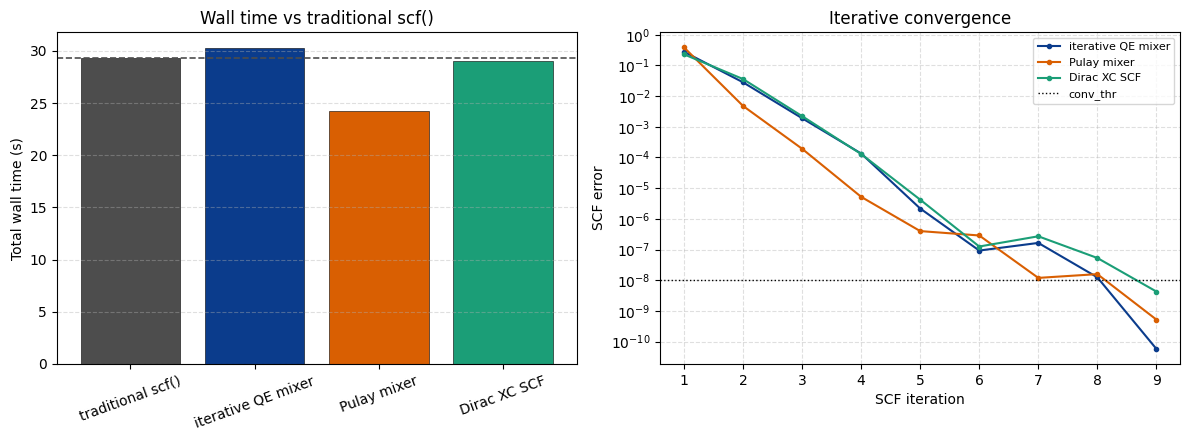

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullLocator

baseline = next(r for r in results if r["label"] == "traditional scf()")
t0 = baseline["t_total"]

print(f"{'scheme':22s}  {'conv':5s}  {'iters':>5s}  {'E (Ry)':>14s}  {'wall (s)':>10s}  {'vs scf()':>8s}")
for r in results:
    ratio = r["t_total"] / t0 if t0 > 0 else float("nan")
    print(
        f"{r['label']:22s}  {str(r['converged']):5s}  {r['n_done']:5d}  "
        f"{r['energy']:14.8f}  {r['t_total']:10.2f}  {ratio:7.2f}x"
    )

colors = {
    "traditional scf()": "#4d4d4d",
    "iterative QE mixer": "#0b3c8c",
    "Pulay mixer": "#d95f02",
    "Dirac XC SCF": "#1b9e77",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = [r["label"] for r in results]
walls = [r["t_total"] for r in results]
axes[0].bar(labels, walls, color=[colors[l] for l in labels], edgecolor="k", lw=0.4)
axes[0].axhline(t0, color="#4d4d4d", ls="--", lw=1.2)
axes[0].set_ylabel("Total wall time (s)")
axes[0].set_title("Wall time vs traditional scf()")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y", ls="--", alpha=0.4)

for r in results:
    if r["iters"]:
        axes[1].semilogy(r["iters"], r["err"], "o-", ms=3, color=colors[r["label"]], label=r["label"])
axes[1].axhline(qe_options["&electrons"]["conv_thr"], color="k", ls=":", lw=1, label="conv_thr")
axes[1].set_xlabel("SCF iteration")
axes[1].set_ylabel("SCF error")
axes[1].set_title("Iterative convergence")
axes[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=15))
axes[1].yaxis.set_minor_locator(NullLocator())
axes[1].minorticks_off()
axes[1].grid(True, which="major", ls="--", alpha=0.4)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()